# The Birthday Paradox

This notebook studies the classical birthday problem:  
Given $n$ individuals, what is the probability that at least two share the same birthday?

We derive the exact probability formula, develop an asymptotic approximation, and validate results using Monte Carlo simulation.

This project illustrates combinatorics, probabilistic modelling, asymptotic analysis, and computational verification.

### 01. Exact Probability

The probability that all birthdays are distinct is:

$$P(\text{no match}) =\prod_{k=0}^{n-1} \frac{365-k}{365}$$

Therefore,

$$P(\text{at least one match}) = 1 - \prod_{k=0}^{n-1} \frac{365-k}{365}$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def birthday_probability(n):
    prob_no_match = 1.0
    for k in range(n):
        prob_no_match *= (365 - k) / 365
    return 1 - prob_no_match

n_values = np.arange(1, 61)
exact_probs = np.array([birthday_probability(n) for n in n_values])

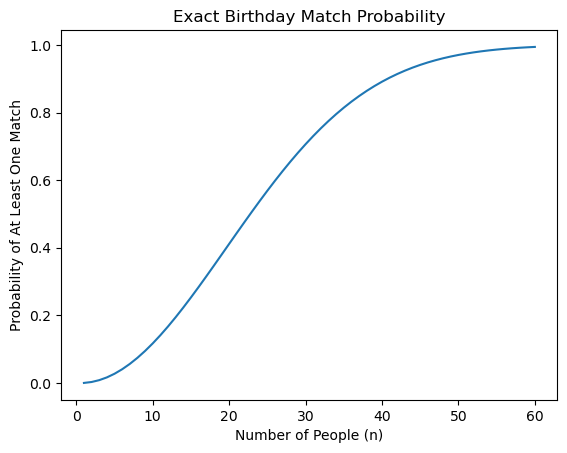

In [ ]:
plt.figure()
plt.plot(n_values, exact_probs)
plt.xlabel("Number of People (n)")
plt.ylabel("Probability of At Least One Match")
plt.title("Exact Birthday Match Probability")
plt.show()

In [ ]:
min(n for n in n_values if birthday_probability(n) > 0.5)

np.int64(23)

### 02. Asymptotic Approximation

Considering the expansion; $\quad\ln(1-x) \approx -x$,

We have: $$\quad P(\text{no match}) \approx \exp\left( -\frac{n(n-1)}{2 \cdot 365} \right)$$

hence, $$\quad P(\text{match}) \approx 1 - \exp\left( -\frac{n(n-1)}{730} \right)$$

In [ ]:
def birthday_approx(n):
    return 1 - np.exp(-(n*(n-1))/(730))

approx_probs = birthday_approx(n_values)

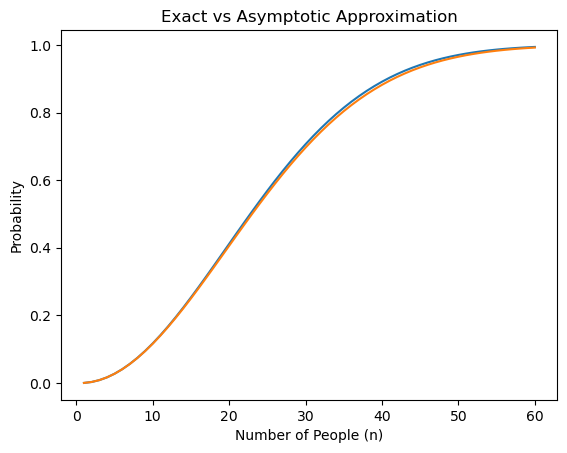

In [ ]:
plt.figure()
plt.plot(n_values, exact_probs)
plt.plot(n_values, approx_probs)
plt.xlabel("Number of People (n)")
plt.ylabel("Probability")
plt.title("Exact vs Asymptotic Approximation")
plt.show()

### 03. Monte Carlo Simulation
Now we validate empirically.

In [ ]:
def simulate_birthday(n, trials=10000):
    count = 0
    for _ in range(trials):
        birthdays = np.random.randint(1, 366, size=n)
        if len(set(birthdays)) < n:
            count += 1
    return count / trials

simulated_probs = np.array([simulate_birthday(n) for n in n_values])

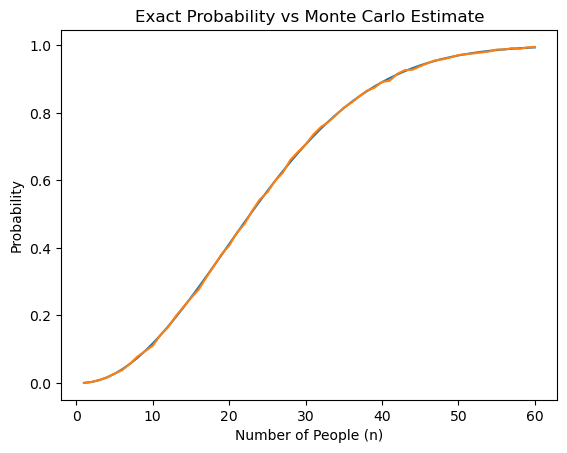

In [ ]:
plt.figure()
plt.plot(n_values, exact_probs)
plt.plot(n_values, simulated_probs)
plt.xlabel("Number of People (n)")
plt.ylabel("Probability")
plt.title("Exact Probability vs Monte Carlo Estimate")
plt.show()

### 04. Expected Collisions
Using linearity of expectation,

$$\text{E[X]} = \binom{n}{2}\frac{1}{365}$$

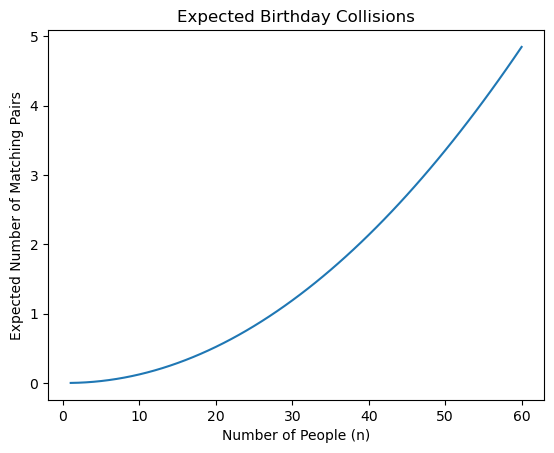

In [ ]:
expected_pairs = (n_values*(n_values-1))/(2*365)

plt.figure()
plt.plot(n_values, expected_pairs)
plt.xlabel("Number of People (n)")
plt.ylabel("Expected Number of Matching Pairs")
plt.title("Expected Birthday Collisions")
plt.show()